Encrypted string's corona graph:


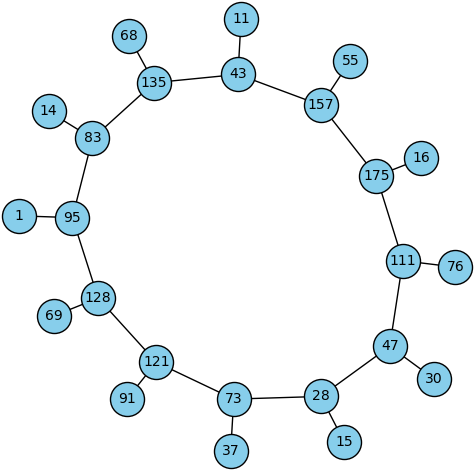

Corona cipher result: True
Encrypted string's bipartite graph's adjacency list representation:
{1: [5, 1], 9: [11, 5], 12: [2, 6], 17: [4, 6], 18: [8, 5]}
Bipartite graph result: True


In [13]:
from sage.all import *
from string import ascii_lowercase
import random

def corona_encrypt(pt: str) -> dict[int, list[int]]:
    n = len(pt)
    a = []
    a = [((ascii_lowercase.index(char) + 1 + n) % 26 or 26) for char in pt.lower()]
    # print(a)

    b = []
    c = []
    b_num = 27
    i = 0
    while(len(b) < n):
        if(gcd(b_num, a[i]) == 1 and b_num > 26):
            inv = pow(a[i], -1, b_num)
            if(inv not in b and inv not in c):
                b.append(b_num)
                c.append(inv)
                i += 1
        b_num += random.randint(1, n)
    # print(b)
    # print(c)

    # Create a random permutation of b
    rand_b = b[:]
    random.shuffle(rand_b)

    G = Graph()
    for i in range(n):
        G.add_vertex(rand_b[i]) # Add core vertex
        G.add_vertex(c[b.index(rand_b[i])]) # Add pendant
        G.add_edge(rand_b[i], c[b.index(rand_b[i])]) # Connect core and pendant
        G.add_edge(rand_b[i], rand_b[(i+1)%n]) # Connect core vertices

    # print(G.to_dictionary())
    print("Encrypted string's corona graph:")
    G.plot(vertex_labels=True, vertex_size=600, vertex_color='skyblue').show() # Uncomment to visualize the graph in Sage terminal
    return G.to_dictionary()

def corona_decrypt(graph: dict[int, list[int]]) -> str:
    b = sorted([node for node, edges in graph.items() if len(edges) == 3])
    # print(b)

    c = []
    for core_node in b:
        for node, edges in graph.items():
            if core_node == edges[0] and len(edges) == 1:
                c.append(node)
                break
    # print(c)

    a = []
    for i in range(len(b)):
        a.append(pow(c[i], -1, b[i]))
    # print(a)

    # print(''.join(ascii_lowercase[((ai - len(a))%26)-1] for ai in a))
    return ''.join(ascii_lowercase[((ai - len(a))%26)-1] for ai in a)

def bipartite_encrypt(pt: str) -> dict[int, list[int]]:
    k = len(pt)
    n = ceil((26/k)+k)
    p = []
    i = 1
    while(len(p) < n):
        if is_prime(i):
            p.append(i)
        i += 1
    # print(n)
    # print(k)
    # print(p)

    table = []
    l = 0
    for i in range(n-k+1):
        table.append([])
        for j in range(k+1):
            if i == 0 and j == 0:
                table[i].append(0)
            elif i == 0 and j != 0:
                table[i].append(p[j-1])
            elif i != 0 and j == 0:
                table[i].append(p[n-k+i-2])
            else:
                if l > 25:
                    table[i].append(0)
                else:
                    table[i].append(ascii_lowercase[l])
                    l += 1
               
    # print("[")
    # for row in table:
    #     print(" ", row, ",")
    # print("]")

    rc = {}
    for letter in pt.lower():
        for row in table:
            if letter in row:
                rc[letter] = (row[0], table[0][row.index(letter)])
                break
    # print(rc)
    
    P_vertices = [rc[letter][0] * rc[letter][1] for letter in rc]

    P = Graph()
    P.add_vertices(P_vertices)
    for i in range(len(P_vertices) - 1):
        P.add_edge(P_vertices[i], P_vertices[i + 1])

    #P.plot(vertex_labels=True, vertex_size=600).show()

    G1_vertices = []
    G2_vertices = set()
    for node in P_vertices:
        G1_vertices.append(int(str(node)[:-1]))
        G2_vertices.add(int(str(node)[-1]))
    G2_vertices = list(G2_vertices)
    
    # print(G1_vertices)
    # print(G2_vertices)

    G = {}
    shorter = G1_vertices if len(G1_vertices) < len(G2_vertices) else G2_vertices
    longer = G1_vertices if len(G1_vertices) > len(G2_vertices) else G2_vertices
    weights = sorted(random.sample(range(1, (n-k)*k), len(longer)))
    # print(weights)
    for i in range(len(longer)):
        iter = i if i < len(shorter) else (len(shorter)-1) - i%len(shorter)
        u = longer[i]
        v = shorter[iter]

        G[weights[i]] = [u, v]
    
    # print(G)
    
    # G = Graph()
    # shorter = G1_vertices if len(G1_vertices) < len(G2_vertices) else G2_vertices
    # longer = G1_vertices if len(G1_vertices) > len(G2_vertices) else G2_vertices
    # weights = sorted(random.sample(range(1, (n-k)*k), len(longer)))
    # print(weights)
    # for i in range(len(longer)):
    #     G.add_vertex(longer[i])
    #     iter = i if i < len(shorter) else (len(shorter)-1) - i%len(shorter)
    #     if shorter[iter] not in G.vertices():
    #         G.add_vertex(shorter[i])
    #         G.add_edge(longer[i], shorter[i], weights[i])
    #         print(f"{longer[i]} - {shorter[i]} : {weights[i]}")
    #     else:
    #         G.add_edge(longer[i], shorter[iter], weights[i])
    #         print(f"{longer[i]} - {shorter[iter]} : {weights[i]}")

    print("Encrypted string's bipartite graph's adjacency list representation:")
    print(G)
    # G.plot(vertex_labels=True, edge_labels=True, vertex_size=600).show()
    # print(G.edges())
    # return G.edges()
    
    return G

def bipartite_decrypt(graph: dict[int, list[int]]) -> str:
    edges_weights = sorted([[(edges[0], edges[1]),weight] for weight, edges in graph.items()], key=lambda x: x[1])
    # print(edges_weights)
    
    P_vertices = [int(f"{edges[0]}{edges[1]}") for edges, _ in edges_weights]
    P = Graph()
    P.add_vertices(P_vertices)
    for i in range(len(P_vertices) - 1):
        P.add_edge(P_vertices[i], P_vertices[i + 1])
    # P.plot(vertex_labels=True, vertex_size=600).show()

    prime_factors = []
    for vertex in P_vertices:
        primes = factor(vertex)
        # print(primes)
        if len(primes) == 1:
            prime_factors.append((primes[0][0], 1))
        else:
            prime_factors.append((primes[1][0], primes[0][0]))
    
    # print(prime_factors)

    k = len(prime_factors)
    n = ceil((26/k)+k)
    p = []
    i = 1
    while(len(p) < n):
        if is_prime(i):
            p.append(i)
        i += 1
    # print(n)
    # print(k)
    # print(p)

    table = []
    l = 0
    for i in range(n-k+1):
        table.append([])
        for j in range(k+1):
            if i == 0 and j == 0:
                table[i].append(0)
            elif i == 0 and j != 0:
                table[i].append(p[j-1])
            elif i != 0 and j == 0:
                table[i].append(p[n-k+i-2])
            else:
                if l > 25:
                    table[i].append(0)
                else:
                    table[i].append(ascii_lowercase[l])
                    l += 1
               
    # print("[")
    # for row in table:
    #     print(" ", row, ",")
    # print("]")

    return ''.join([table[[table.index(row) for row in table if row[0] == x][0]][table[0].index(y)] for (x, y) in prime_factors])


print(f'Corona cipher result: {corona_decrypt(corona_encrypt('cryptography')) == 'cryptography'}')

print(f'Bipartite graph result: {bipartite_decrypt(bipartite_encrypt('graph')) == 'graph'}')
